# **Import Necessary Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
import seaborn as sns
print("Import Completed!!")

Import Completed!!


# **Data Exploration**

## *Load the data*

In [3]:
df = pd.read_csv("C:\\Users\\abhay\\OneDrive\\Desktop\\ML learning\\Linear Regression\\Dilevary Time\\Data\\delivery_time.csv")
print("Data Loaded")

Data Loaded


## *Exploration*

In [4]:
# Shape
df.shape

(560, 7)

In [5]:
# First 5 Rows
df.head()

,distance_km,package_weight_kg,num_stops,traffic_index,is_weekend,warehouse_distance_km,delivery_time_hours
0,32.3,5.78,14.0,1.9,0.0,9.1,10.47
1,24.4,12.07,2.0,NaN,1.0,7.3,9.76
2,12.3,28.46,7.0,9.2,0.0,7.0,11.53
3,13.0,4.67,4.0,2.5,0.0,15.7,-5.00
4,35.2,23.02,2.0,9.7,1.0,2.0,11.31


In [6]:
# Last 5 Rows
df.tail()

,distance_km,package_weight_kg,num_stops,traffic_index,is_weekend,warehouse_distance_km,delivery_time_hours
555,66.5,27.57,3.0,4.8,1.0,10.9,12.74
556,53.9,27.94,13.0,9.3,0.0,9.9,15.88
557,10.5,11.95,10.0,2.4,1.0,6.0,7.00
558,70.5,17.67,8.0,2.8,0.0,8.3,11.26
559,5.7,3.10,12.0,8.3,1.0,13.5,11.45


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   distance_km            560 non-null    float64
 1   package_weight_kg      548 non-null    float64
 2   num_stops              560 non-null    float64
 3   traffic_index          542 non-null    float64
 4   is_weekend             560 non-null    float64
 5   warehouse_distance_km  560 non-null    float64
 6   delivery_time_hours    560 non-null    float64
dtypes: float64(7)
memory usage: 30.8 KB


In [8]:
# Numeric Calulation
df.describe()

,distance_km,package_weight_kg,num_stops,traffic_index,is_weekend,warehouse_distance_km,delivery_time_hours
count,560.000000,548.000000,560.000000,542.000000,560.000000,560.000000,560.000000
mean,41.158214,15.233887,7.658929,5.442620,0.308929,10.365357,11.236429
std,41.233019,8.461397,5.506843,2.643908,0.462465,5.505413,2.813356
min,1.000000,0.530000,1.000000,1.000000,0.000000,1.000000,-5.000000
25%,19.500000,8.185000,4.000000,3.100000,0.000000,5.600000,9.320000
50%,39.200000,14.795000,7.000000,5.400000,0.000000,10.200000,11.285000
75%,60.400000,22.582500,11.000000,7.800000,1.000000,15.325000,13.162500
max,850.000000,29.960000,99.000000,10.000000,1.000000,19.800000,19.400000


In [9]:
# NaN values
df.isna().sum()

distance_km               0
package_weight_kg        12
num_stops                 0
traffic_index            18
is_weekend                0
warehouse_distance_km     0
delivery_time_hours       0
dtype: int64

In [10]:
# Duplicates
df.duplicated().sum()

np.int64(10)

# **Data Cleaning**

In [15]:
# Create Copy of Original
df_copy = df.copy()
print("Copy Created")

Copy Created


In [16]:
# Impossible values
df_copy.loc[df_copy['delivery_time_hours']<=0,'delivery_time_hours'] = np.nan

In [17]:
# Handel outliers on Distance Colume
Q1 = df_copy['distance_km'].quantile(0.25)
Q3 = df_copy['distance_km'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_copy.loc[df_copy['distance_km'] < lower, 'distance_km'] = np.nan
df_copy.loc[df_copy['distance_km'] > upper, 'distance_km'] = np.nan

Q1 = df_copy['num_stops'].quantile(0.25)
Q3 = df_copy['num_stops'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_copy.loc[df_copy['num_stops'] < lower, 'num_stops'] = np.nan
df_copy.loc[df_copy['num_stops'] > upper, 'num_stops'] = np.nan

print("Outliers Handeled sucessfully")

Outliers Handeled sucessfully


In [18]:
df_copy.isna().sum()

distance_km               1
package_weight_kg        12
num_stops                 1
traffic_index            18
is_weekend                0
warehouse_distance_km     0
delivery_time_hours       1
dtype: int64

In [19]:
df_copy["distance_km"] = df_copy["distance_km"].fillna(df_copy['distance_km'].median())
df_copy["package_weight_kg"] = df_copy["package_weight_kg"].fillna(df_copy['package_weight_kg'].median())
df_copy["traffic_index"] = df_copy["traffic_index"].fillna(df_copy['traffic_index'].median())
df_copy["delivery_time_hours"] = df_copy["delivery_time_hours"].fillna(df_copy['delivery_time_hours'].median())
df_copy["num_stops"] = df_copy["num_stops"].fillna(df_copy['num_stops'].median())

In [20]:
df_copy.isna().sum()

distance_km              0
package_weight_kg        0
num_stops                0
traffic_index            0
is_weekend               0
warehouse_distance_km    0
delivery_time_hours      0
dtype: int64

In [21]:
df_copy.drop_duplicates(inplace=True)

In [22]:
df_copy.duplicated().sum()

np.int64(0)

In [23]:
df_copy.describe()

,distance_km,package_weight_kg,num_stops,traffic_index,is_weekend,warehouse_distance_km,delivery_time_hours
count,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000,550.000000
mean,39.869818,15.260982,7.454545,5.450182,0.303636,10.363273,11.268873
std,22.931587,8.349769,3.917260,2.600012,0.460246,5.526113,2.731984
min,1.000000,0.530000,1.000000,1.000000,0.000000,1.000000,3.900000
25%,19.750000,8.722500,4.000000,3.100000,0.000000,5.525000,9.345000
50%,39.300000,14.795000,7.000000,5.400000,0.000000,10.200000,11.290000
75%,60.350000,22.395000,11.000000,7.775000,1.000000,15.375000,13.167500
max,79.800000,29.960000,14.000000,10.000000,1.000000,19.800000,19.400000


## **Visual**

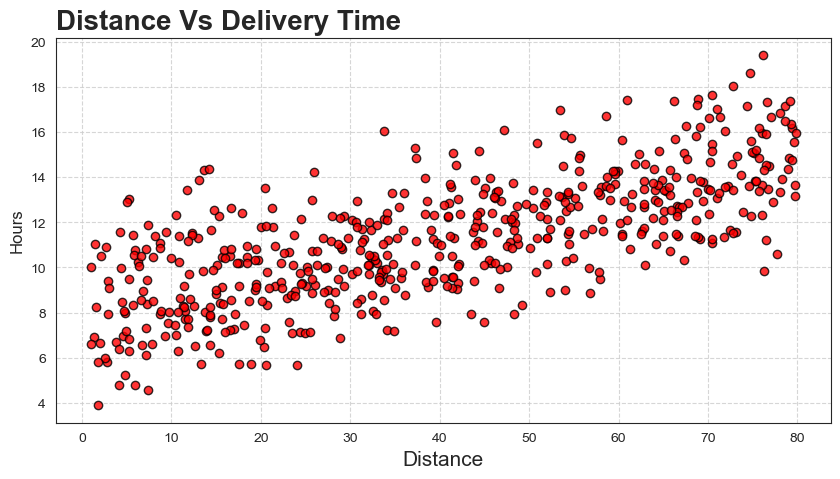

In [ ]:
plt.figure(figsize=(10,5))
sns.set_style('white')

plt.scatter(df_copy['distance_km'],df_copy['delivery_time_hours'],color='red',alpha=0.8,edgecolors='black')
plt.title("Distance Vs Delivery Time",weight='bold',fontsize=20,loc='left')
plt.grid(True,linestyle='--',alpha=0.8)
plt.xlabel("Distance",fontsize=15)
plt.ylabel("Hours",fontsize=12)
plt.tight_layout()
plt.show()

# **Data Preperation**

In [24]:
X = df_copy[['distance_km','package_weight_kg','num_stops','traffic_index','is_weekend','warehouse_distance_km']]
y = df_copy['delivery_time_hours']

print("X shape:", X.shape)
print("y shape:", y.shape)
print()
print("Features:")
print(X.head())

X shape: (550, 6)
y shape: (550,)

Features:
   distance_km  package_weight_kg  num_stops  traffic_index  is_weekend  \
0         32.3               5.78       14.0            1.9         0.0   
1         24.4              12.07        2.0            5.4         1.0   
2         12.3              28.46        7.0            9.2         0.0   
3         13.0               4.67        4.0            2.5         0.0   
4         35.2              23.02        2.0            9.7         1.0   

   warehouse_distance_km  
0                    9.1  
1                    7.3  
2                    7.0  
3                   15.7  
4                    2.0  


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=42) 

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (440, 6)
X_test shape:  (110, 6)
y_train shape: (440,)
y_test shape:  (110,)


# **Model**

##  *Train*

In [26]:
model = LinearRegression()

model.fit(X_train,y_train)

print("Model Trained")

Model Trained


### *Training Evaluation*

In [27]:
print(f"Intercept (β₀): {model.intercept_:.4f}")
print()
print("Feature Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:22} → {coef:.4f}")

Intercept (β₀): 1.5121

Feature Coefficients:
  distance_km            → 0.0795
  package_weight_kg      → 0.0527
  num_stops              → 0.2879
  traffic_index          → 0.3898
  is_weekend             → 1.1743
  warehouse_distance_km  → 0.1095


## *Test*

In [28]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred.round(3),
    'Difference': (y_test.values - y_pred).round(3)
})

comparison.head(10)

,Actual,Predicted,Difference
0,10.32,10.149,0.171
1,8.78,9.072,-0.292
2,8.44,7.976,0.464
3,9.20,9.797,-0.597
4,11.52,11.907,-0.387
5,14.27,14.456,-0.186
6,8.30,9.262,-0.962
7,11.16,9.786,1.374
8,10.35,10.694,-0.344
9,10.77,10.423,0.347


### *Test Evaluation*

In [29]:
MAE = mean_absolute_error(y_true=y_test,y_pred=y_pred)
MSR = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(MSR)
r2   = r2_score(y_test, y_pred)

print("MAE :-",round(MAE,3))
print("MSE :-",round(MSR,3))
print("RMSE :-",round(RMSE,3))
print("R2 Score :-", round(r2,3))

MAE :- 0.538
MSE :- 0.428
RMSE :- 0.654
R2 Score :- 0.949


## *Test With Your Own Data*

In [25]:
# 
distance = float(input("Enter the Distance(Km) Of the Package:- "))
weight = float(input("Enter the Weight(Kg) Of the Package:- "))
stops = float(input("How many stops your Package Routes have:- "))
traffic = float(input("Range of traffic on the day of Dilivery(1-10):- "))
weekend = bool(input("Is it Weekend(Leave blank If not):- "))
warehouse = float(input("Distance of nearest Warehouse:- "))


features = ['distance_km','package_weight_kg','num_stops','traffic_index','is_weekend','warehouse_distance_km']
user_data = [[distance,weight,stops,traffic,weekend,warehouse]]

X_user = pd.DataFrame(user_data,columns=features)

y_user = model.predict(X_user)[0]

print(f"Based on the Provided Data your Package should diliver around {y_user.round(2)} hours")

Based on the Provided Data your Package should diliver around 4.23 hours


# **Visulalisation**

## *Actual Vs Pridicted*

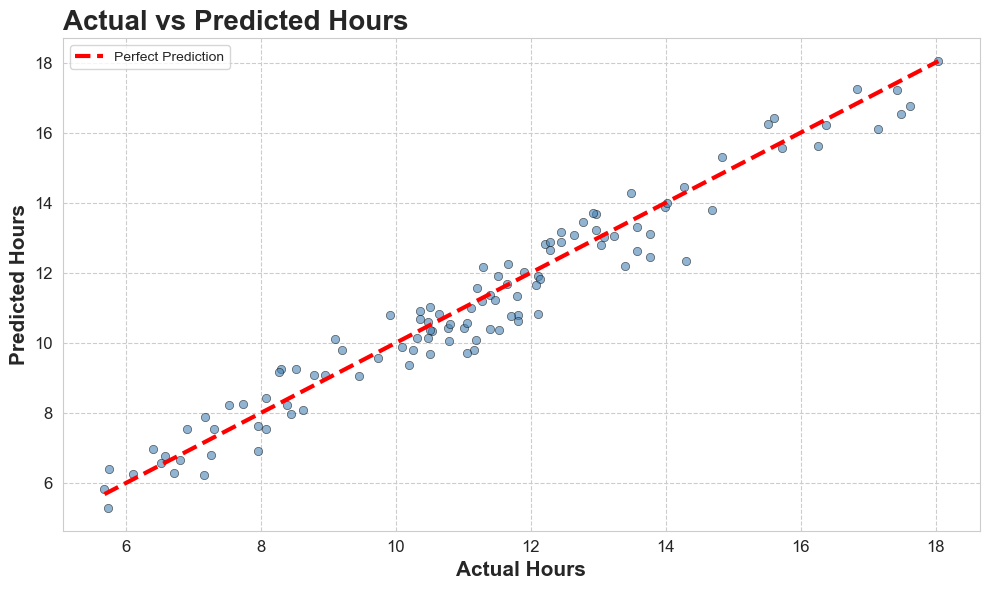

In [33]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

# scatter plot
plt.scatter(
    y_test, y_pred,
    alpha=0.6,
    color="steelblue",
    edgecolors="black",
    linewidths=0.5
)

# perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=3,
    label="Perfect Prediction",
    color = "red"
)

# labels
plt.xlabel("Actual Hours",weight = 'bold',fontsize=15)
plt.ylabel("Predicted Hours",weight = 'bold',fontsize=15 )
plt.title("Actual vs Predicted Hours", fontsize=20, weight="bold",loc='left')
ax = plt.gca()
ax.tick_params("both",labelsize=12)
plt.legend()
plt.grid(True, linestyle="--")

plt.tight_layout()
plt.show()
